In [1]:
%load_ext autoreload
%autoreload 2

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv, GINConv, GATConv, GATv2Conv
from matplotlib import pyplot as plt
import networkx as nx
import torch

### Phase 0

In [21]:
cora_dataset = Planetoid(root='data', name='Cora')
data = cora_dataset[0]
data.to("cuda")
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

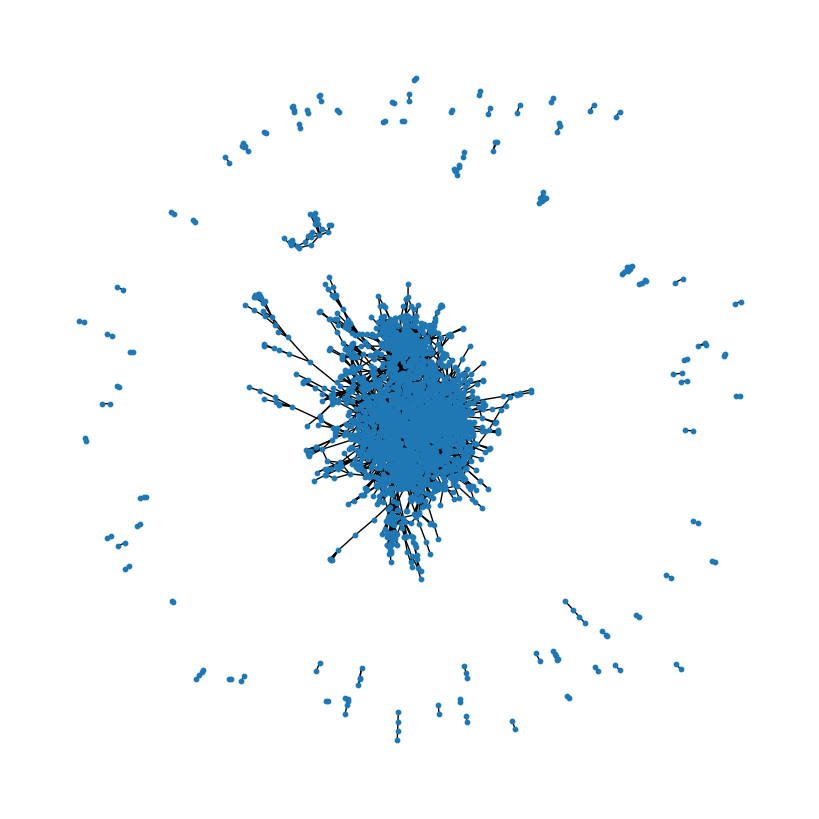

In [ ]:
graph = to_networkx(data, to_undirected=True)

plt.figure(figsize=(8, 8))
nx.draw(graph, node_size=10)
plt.show()

### Phase 1

#### Node-level Cora dataset

  2%|▏         | 19/1000 [00:00<00:10, 91.01it/s]

Epoch: 0, Train Loss: 1.963632583618164, Val Loss: 1.9075015783309937


  7%|▋         | 67/1000 [00:00<00:08, 112.00it/s]


Epoch: 50, Train Loss: 0.20694704353809357, Val Loss: 1.839340090751648
Early stopping at epoch 67
Training complete. Best validation loss: 1.237755298614502


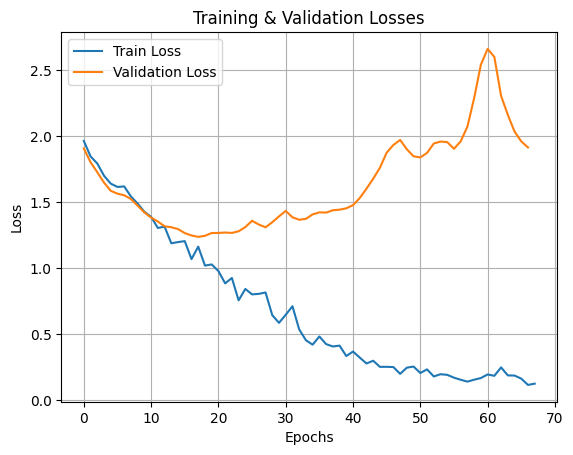

Classification Report:
               precision    recall  f1-score   support

           0      0.400     0.815     0.537       130
           1      0.773     0.824     0.798        91
           2      0.848     0.812     0.830       144
           3      0.896     0.621     0.733       319
           4      0.857     0.725     0.785       149
           5      0.740     0.748     0.744       103
           6      0.816     0.625     0.708        64

    accuracy                          0.721      1000
   macro avg      0.762     0.739     0.734      1000
weighted avg      0.786     0.721     0.735      1000



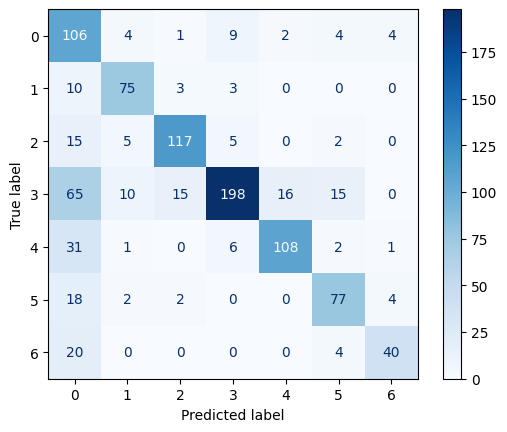

In [ ]:
from node_level_train import main

hyperparameters = {
    "learning_rate": 0.0020,
    "epochs": 1000,
    "log_interval": 50,
    "layers": [64, 64],
    "dropout": 0.5,
    "patience": 50,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
main(GINConv,hyperparameters)

  1%|          | 2/200 [00:00<00:14, 13.40it/s]

Epoch: 0, Train Loss: 1.9460126161575317, Val Loss: 1.9297860860824585


 27%|██▋       | 54/200 [00:02<00:06, 21.13it/s]

Epoch: 50, Train Loss: 0.2624259293079376, Val Loss: 0.6848875880241394


 46%|████▋     | 93/200 [00:04<00:05, 20.39it/s]

Early stopping at epoch 93
Training complete. Best validation loss: 0.627480149269104


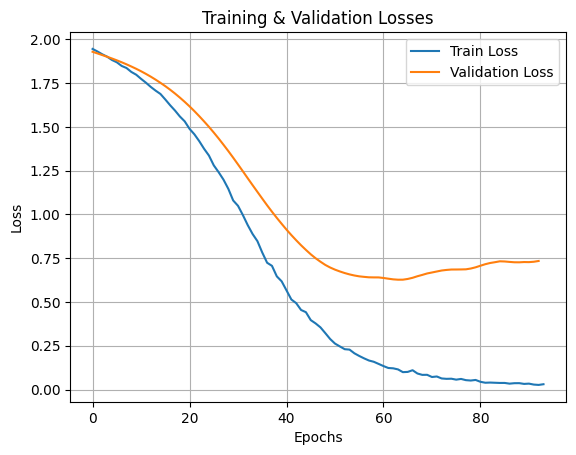

Classification Report:
               precision    recall  f1-score   support

           0      0.688     0.746     0.716       130
           1      0.767     0.868     0.814        91
           2      0.858     0.924     0.890       144
           3      0.904     0.712     0.796       319
           4      0.753     0.879     0.811       149
           5      0.830     0.806     0.818       103
           6      0.711     0.844     0.771        64

    accuracy                          0.804      1000
   macro avg      0.787     0.825     0.802      1000
weighted avg      0.814     0.804     0.804      1000



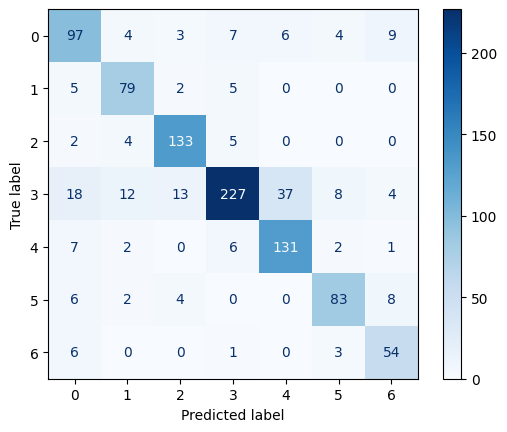

In [ ]:
from node_level_train import main

hyperparameters = {
    "learning_rate": 0.0001,
    "epochs": 200,
    "log_interval": 50,
    "layers": [2048, 1024, 512],
    "dropout": 0.5,
    "patience": 30,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
main(GCNConv,hyperparameters)

#### Graph-level

##### MUTAG dataset (binary classification)

MUTAG: 188 graphs


  0%|          | 4/1000 [00:00<00:32, 30.65it/s]

Epoch: 0, Train Loss: 0.5838965773582458, Val Loss: 0.6307035088539124


  5%|▌         | 54/1000 [00:01<00:33, 27.95it/s]

Epoch: 50, Train Loss: 0.6938744187355042, Val Loss: 0.3636210560798645


...

Epoch: 250, Train Loss: 0.2736314535140991, Val Loss: 0.19617503881454468


 30%|███       | 303/1000 [00:10<00:23, 30.15it/s]

Epoch: 300, Train Loss: 0.30691614747047424, Val Loss: 0.18821890652179718


 33%|███▎      | 327/1000 [00:11<00:23, 28.32it/s]

Early stopping at epoch 327
Training complete. Best validation loss: 0.18153253197669983


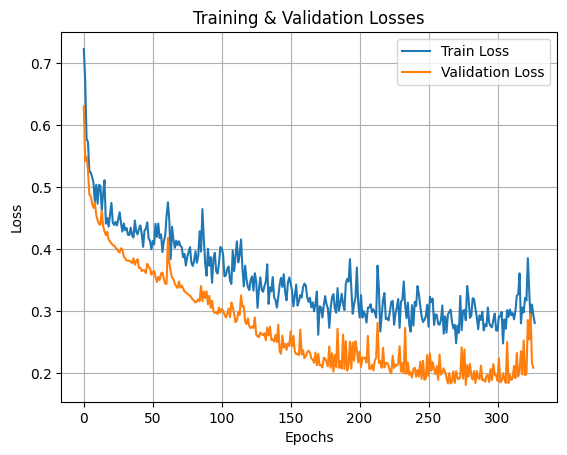

Classification Report:
               precision    recall  f1-score   support

           0      0.833     0.833     0.833         6
           1      0.923     0.923     0.923        13

    accuracy                          0.895        19
   macro avg      0.878     0.878     0.878        19
weighted avg      0.895     0.895     0.895        19



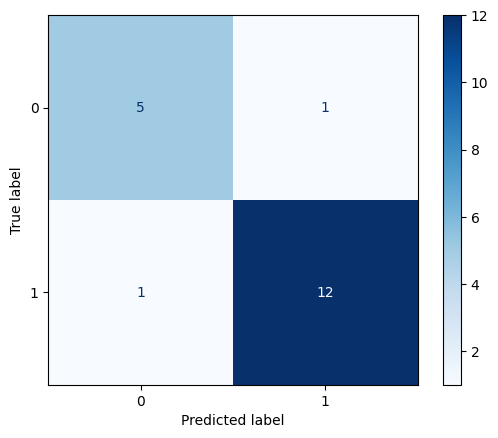

In [52]:
from graph_level_train import main

hyperparameters = {
    "batch_size": 32,
    "learning_rate": 0.0020,
    "epochs": 1000,
    "log_interval": 50,
    "layers": [64, 64],
    "dropout": 0.5,
    "patience": 50,
    "dataset": "MUTAG", # QM9 or MUTAG
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "head_type": "classification",
    "split": [150, 19, 19]
}
main(hyperparameters)

QM9: 130831 molecules


  0%|          | 0/1000 [00:00<?, ?it/s]

torch.Size([64]) torch.Size([64])
tensor([-11.5580,  -7.7389,  -9.8346,  -9.9982,  -6.4951,  -8.9540,  -9.3479,
         -7.4134, -11.4037,  -8.1920, -10.6043,  -5.4524, -12.3136, -12.4521,
        -10.9481,  -8.1296,  -6.6164,  -7.9501,  -7.5831, -12.1206,  -9.2611,
        -10.8120, -12.1125,  -9.2038, -13.2962, -12.9110,  -7.3992,  -7.7130,
        -10.4037, -13.1195, -11.2223, -10.3655, -12.7628,  -9.2498, -13.4524,
        -10.6195,  -7.6009, -10.9340,  -9.7698,  -5.4371,  -8.5275,  -8.7800,
         -9.3132, -11.2761,  -6.1801,  -9.1025,  -9.5944,  -9.5320,  -9.3455,
         -6.6270,  -7.2474, -11.9031,  -8.0148,  -8.8937, -11.1574,  -9.3300,
        -13.4760,  -8.4303, -10.0761, -10.6677,  -8.8888,  -7.1482,  -8.8027,
        -12.0873], device='cuda:0', grad_fn=<SqueezeBackward0>) tensor([ 0.4299, -0.1497,  2.3756,  1.8994,  0.8680,  0.0844,  2.1960,  0.0163,
         1.1891, -0.1034, -0.2204, -0.3293,  0.1252,  2.0871,  1.7687, -0.6640,
        -0.5469,  0.0571, -0.7728, -0.68

  0%|          | 0/1000 [00:30<?, ?it/s]

Epoch: 0, Train Loss: 0.5755804777145386, Val Loss: 0.7343900203704834
Training complete. Best validation loss: 0.7343900203704834


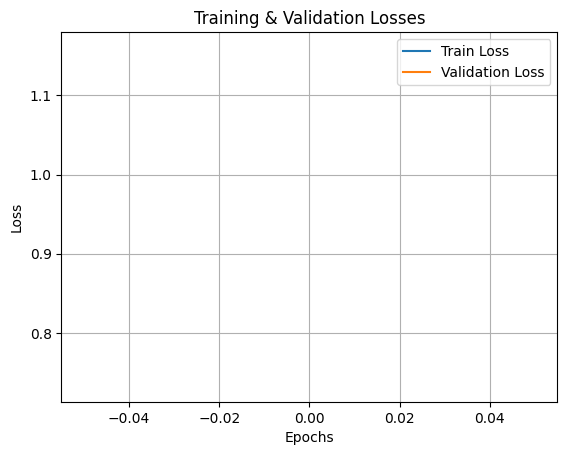

(10831,) (10831,)
Regression Evaluation:
MAE: 0.7108
R² Score: 0.5531


In [ ]:
from graph_level_train import main

hyperparameters = {
    "batch_size": 64,
    "learning_rate": 0.0020,
    "epochs": 1000,
    "log_interval": 50,
    "layers": [64],
    "dropout": 0.5,
    "patience": 20,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dataset": "QM9", # QM9 or MUTAG
    "head_type": "regression",
    "target_property_index": 3,  # Example: 3 = mu, dipole moment
    "split": [110000, 10000, 10831],  # Example: [110000, 10000, 10831] for QM9
}
main(hyperparameters)

In [44]:

from torch_geometric.datasets import TUDataset, QM9
dataset = QM9(root="data/QM9")

In [48]:
dataset[0].y.shape  # Check the shape of the target property

torch.Size([1, 19])

In [43]:
from graph_level_train import load_dataset

dataset, dataset_list = load_dataset("QM9", "cuda")

  0%|          | 0/130831 [00:00<?, ?it/s]


IndexError: index 3 is out of bounds for dimension 0 with size 1

In [ ]:
| Split      | Size (approx.) |
| ---------- | -------------- |
| Train      | 110,000        |
| Validation | 10,000         |
| Test       | 10,831         |
| **Total**  | **130,831**    |


tensor(3.1865, device='cuda:0')

In [26]:

from torch_geometric.datasets import TUDataset, QM9
from tqdm import tqdm

qm9_dataset = QM9(root='data/QM9')  # Complete adds missing edges
print(f"QM9: {len(qm9_dataset)} molecules")

# Example: choose one target property from QM9 (e.g., 0 = mu, dipole moment)
target_property_index = 3
for data in tqdm(qm9_dataset):
    data.y = data.y[:, target_property_index]  # keep only the selected target

print(f"QM9 sample target shape: {data.y.shape}")

QM9: 130831 molecules


100%|██████████| 130831/130831 [00:20<00:00, 6501.22it/s]

QM9 sample target shape: torch.Size([1])


In [28]:
qm9_dataset[0].y

tensor([[    0.0000,    13.2100,   -10.5499,     3.1865,    13.7363,    35.3641,
             1.2177, -1101.4878, -1101.4098, -1101.3840, -1102.0229,     6.4690,
           -17.1722,   -17.2868,   -17.3897,   -16.1519,   157.7118,   157.7100,
           157.7070]])